In [4]:
# Ultralytics（YOLOv8）をインストール
!pip install ultralytics --upgrade -q

# Google Drive をマウント（任意）
from google.colab import drive
drive.mount('/content/drive')  # ←必要であれば


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 31.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 70.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 79.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 64.2 MB/s eta 0:00:00
Mounted at /content/drive


In [6]:
# Colab に zip をアップロード（実行後、ファイル選択）
from google.colab import files
uploaded = files.upload()


Saving dataset.zip to dataset.zip


In [7]:
# zip ファイルを解凍
import zipfile
import os

zip_path = "/content/dataset.zip"  # ← アップしたzip名に変更
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


In [8]:
yaml_content = """
path: /content/dataset/dataset
train: images/train
val: images/val
nc: 3
names: ['raw', 'middle', 'mature']
"""

with open('/content/dataset/data.yaml', 'w') as f:
    f.write(yaml_content)


In [9]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')
model.train(data='/content/dataset/data.yaml', epochs=100, imgsz=640, batch=8)


100%|██████████| 6.25M/6.25M [00:00<00:00, 206MB/s]

Ultralytics 8.3.156 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)


engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plots=True, pose=12.0, pretrained=True, profile=False, project=None, rect=False, resume=False, retina_masks=False, save

100%|██████████| 755k/755k [00:00<00:00, 106MB/s]

Overriding model.yaml nc=80 with nc=3

                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics

...

                   all          6         39      0.695     0.0952      0.112     0.0603



100 epochs completed in 0.318 hours.
Optimizer stripped from runs/detect/train/weights/last.pt, 6.3MB
Optimizer stripped from runs/detect/train/weights/best.pt, 6.3MB

Validating runs/detect/train/weights/best.pt...
Ultralytics 8.3.156 🚀 Python-3.11.13 torch-2.6.0+cu124 CPU (Intel Xeon 2.20GHz)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 1/1 [00:01<00:00,  1.40s/it]


                   all          6         39      0.362     0.0952      0.112     0.0603
                   raw          4         14      0.646      0.143      0.138     0.0361
                middle          4         18          0          0     0.0442     0.0106
                mature          4          7      0.439      0.143      0.155      0.134
Speed: 2.4ms preprocess, 211.2ms inference, 0.0ms loss, 10.2ms postprocess per image
Results saved to runs/detect/train


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x79ed85f94a10>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.04

In [11]:
!ls runs/detect/*/weights


best.pt  last.pt



image 1/1 /content/dataset/dataset/images/val/compost_val1.jpg: 576x640 1 raw, 1 mature, 199.4ms
Speed: 6.3ms preprocess, 199.4ms inference, 4.5ms postprocess per image at shape (1, 3, 576, 640)
Results saved to runs/detect/predict


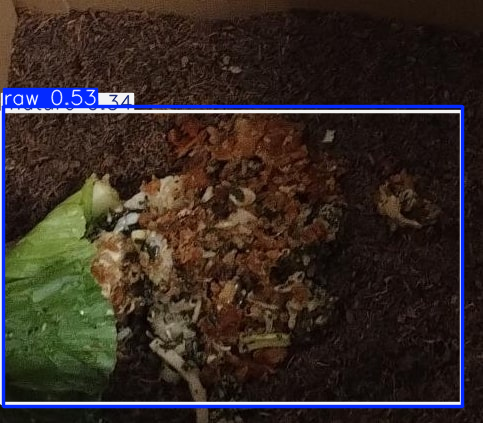

In [14]:
from ultralytics import YOLO

# 学習済みモデルのパス
model_path = 'runs/detect/train/weights/best.pt'  # best.ptがあるならこれ

# モデルをロード
model = YOLO(model_path)

# 推論したい画像パス（例）
img_path = '/content/dataset/dataset/images/val/compost_val1.jpg'

# 推論実行（結果はデフォルトで表示＆保存されます）
results = model.predict(source=img_path, save=True)

# 結果の表示（Jupyter/Colabならこれで画像が見えます）
results[0].show()



image 1/1 /content/dataset/dataset/images/val/compost_val2.jpg: 640x576 1 mature, 187.1ms
Speed: 4.1ms preprocess, 187.1ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 576)
Results saved to runs/detect/predict2


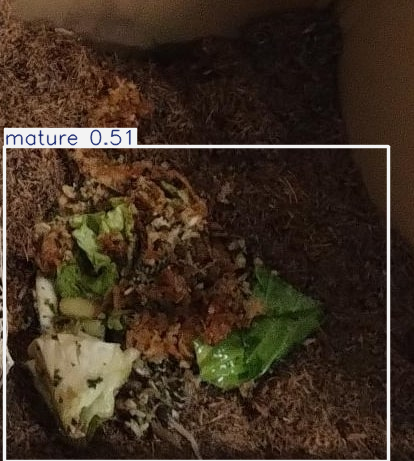

In [15]:
from ultralytics import YOLO

model = YOLO('runs/detect/train/weights/best.pt')

img_path = '/content/dataset/dataset/images/val/compost_val2.jpg'

results = model.predict(source=img_path, save=True)

# resultsはリストなので、2枚目の結果を表示
results[0].show()



image 1/6 /content/dataset/dataset/images/val/compost_val1.jpg: 576x640 1 raw, 1 mature, 188.6ms
image 2/6 /content/dataset/dataset/images/val/compost_val2.jpg: 640x576 1 mature, 189.9ms
image 3/6 /content/dataset/dataset/images/val/compost_val3.jpg: 640x640 1 mature, 231.5ms
image 4/6 /content/dataset/dataset/images/val/compost_val4.jpg: 448x640 1 raw, 1 middle, 156.5ms
image 5/6 /content/dataset/dataset/images/val/compost_val5.jpg: 640x640 1 raw, 201.5ms
image 6/6 /content/dataset/dataset/images/val/compost_val6.jpg: 512x640 (no detections), 181.8ms
Speed: 4.3ms preprocess, 191.6ms inference, 1.3ms postprocess per image at shape (1, 3, 512, 640)
image 1


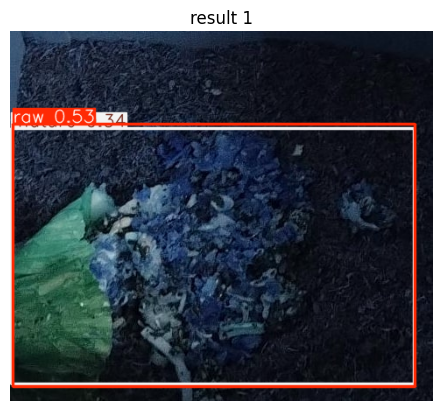

image 2


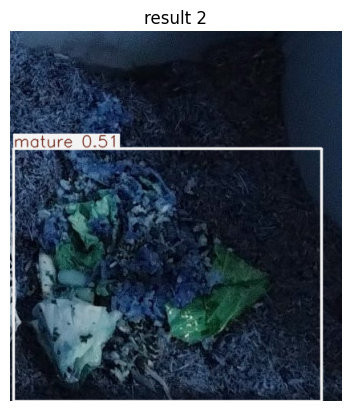

image 3


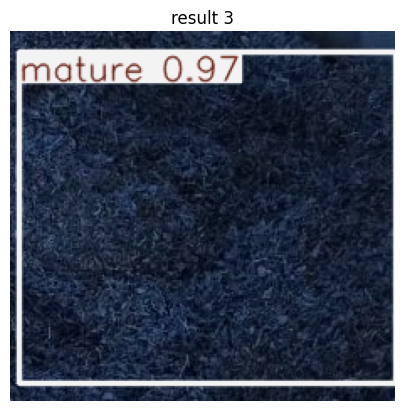

image 4


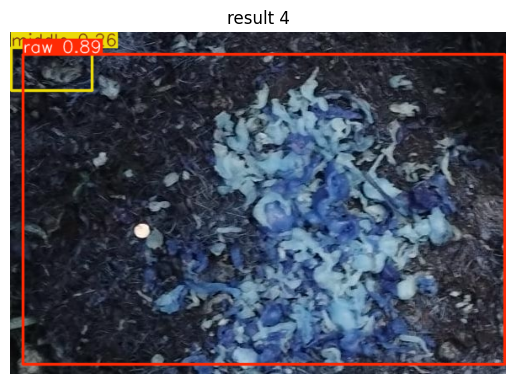

image 5


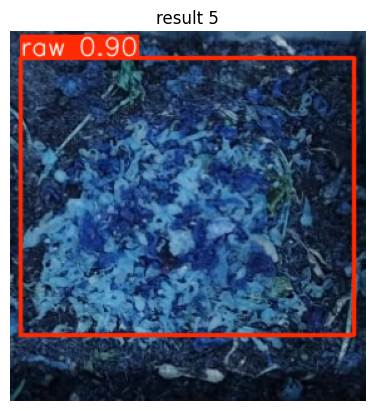

image 6


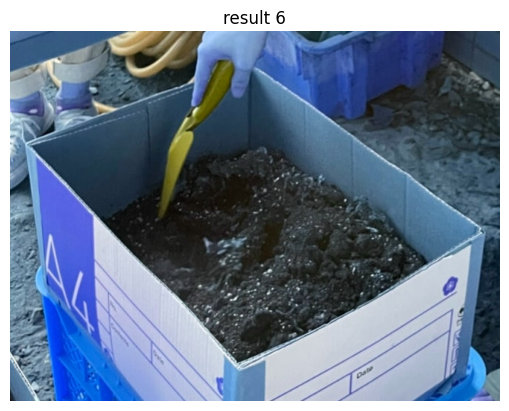

In [16]:
from ultralytics import YOLO
import matplotlib.pyplot as plt
import os

# モデル読み込み
model = YOLO('runs/detect/train/weights/best.pt')

# 画像フォルダ
val_dir = '/content/dataset/dataset/images/val'

# 推論実行（フォルダ内のすべての画像）
results = model.predict(source=val_dir, save=False)

# 結果を順に表示
for i, res in enumerate(results):
    print(f"image {i+1}")
    img = res.plot()
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"result {i+1}")
    plt.show()


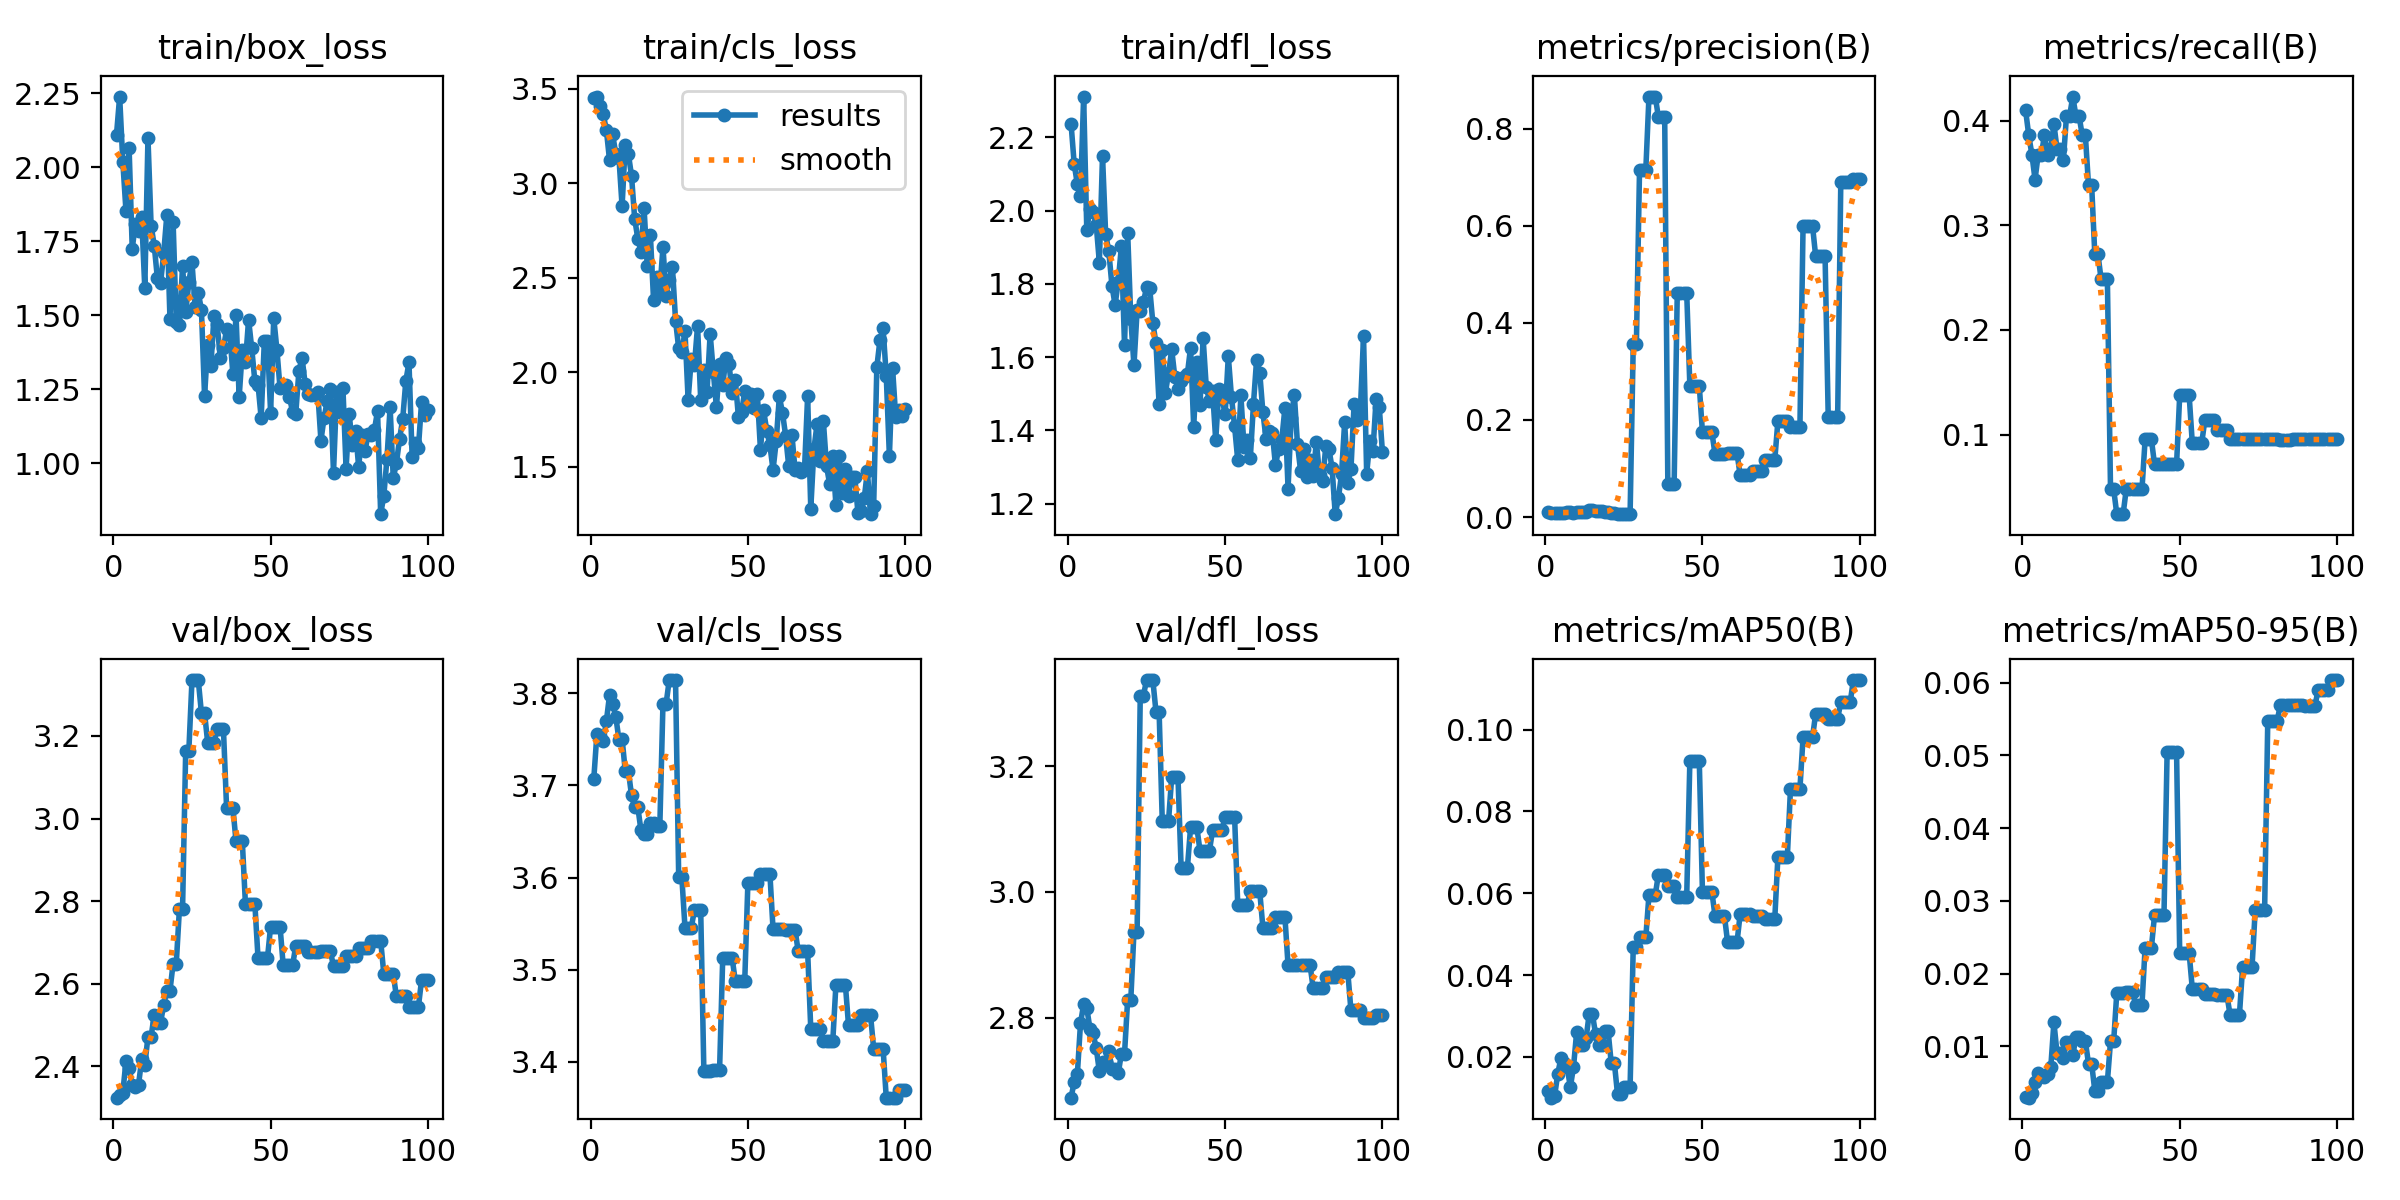

In [17]:
from IPython.display import Image, display

display(Image(filename='runs/detect/train/results.png'))
